# DeBERTa-v3-base Fine-Tuning for Text Complexity Classification

**Task:** 3-class text complexity prediction — `A1-A2` (0), `B1-B2` (1), `C1-C2` (2)  
**Model:** `microsoft/deberta-v3-base`  
**Framework:** Hugging Face Transformers + PyTorch  

---
### Notebook Structure
1. Setup & Installations
2. Local Paths & Existing Run
3. Configuration
4. Load & Explore Data
5. Tokenization & Dataset Preparation
6. Model Initialization
7. Training
8. Checkpoint Resume (optional)
9. Final Evaluation on Test Set
10. Save Model & Results
11. Plot Training History

## 1. Setup & Installations

In [ ]:
# Optional if this local kernel is missing dependencies:
# %pip install transformers==4.40.0 datasets accelerate sentencepiece protobuf scikit-learn pandas pyarrow matplotlib seaborn

import importlib.util

required_modules = [
    'transformers',
    'datasets',
    'accelerate',
    'sentencepiece',
    'pandas',
    'pyarrow',
    'sklearn',
    'matplotlib',
    'seaborn',
]
missing_modules = [name for name in required_modules if importlib.util.find_spec(name) is None]
if missing_modules:
    raise ImportError(
        'Missing notebook dependencies: '
        + ', '.join(missing_modules)
        + '. Install them in this local environment before continuing.'
    )

print('Notebook dependencies available in the local kernel.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 36.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.2.3 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
Sat Mar  7 21:22:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile U

In [ ]:
import os
import json
import math
import random
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_cosine_schedule_with_warmup,
    set_seed,
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

HAS_MPS = hasattr(torch.backends, 'mps') and torch.backends.mps.is_built() and torch.backends.mps.is_available()
DEVICE = torch.device('mps' if HAS_MPS else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
elif DEVICE.type == 'mps':
    print('  Apple Silicon Metal backend enabled')


Using device: cpu


## 2. Local Paths & Existing Run

In [ ]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'code.ipynb').exists() and (candidate / 'data').exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = PROJECT_ROOT / 'models' / 'deberta_v3_base_complexity_train_pool_20260307_174910'
ARCHIVE_BEST_MODEL_DIR = OUTPUT_DIR / 'archive' / 'best_model'
ROOT_BEST_MODEL_DIR = OUTPUT_DIR / 'best_model'
ROOT_BEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Rehydrate the root best-model directory so the original notebook logic keeps working locally.
if ARCHIVE_BEST_MODEL_DIR.exists():
    for item in ARCHIVE_BEST_MODEL_DIR.iterdir():
        if item.name == '.DS_Store':
            continue
        target = ROOT_BEST_MODEL_DIR / item.name
        if target.exists():
            continue
        try:
            if item.is_dir():
                os.symlink(item.resolve(), target, target_is_directory=True)
            else:
                os.symlink(item.resolve(), target)
        except Exception:
            if item.is_dir():
                shutil.copytree(item, target)
            else:
                shutil.copy2(item, target)

TRAIN_FILE = DATA_DIR / 'train_pool_train.parquet'
VAL_FILE = DATA_DIR / 'train_pool_val.parquet'
TEST_FILE = DATA_DIR / 'train_pool_test.parquet'

for file_path in [TRAIN_FILE, VAL_FILE, TEST_FILE]:
    assert file_path.exists(), f'File not found: {file_path}'

print(f'Project root: {PROJECT_ROOT}')
print('All data files found.')
print(f'Outputs will be saved to: {OUTPUT_DIR}')

Mounted at /content/drive
All data files found.
Outputs will be saved to: /content/drive/MyDrive/mago_text_scoring/complexity_colab/deberta_complexity_output


## 3. Configuration

All hyper-parameters are centralised here for easy tuning.

In [ ]:
# ─────────────────────────────────────────────
#  Central configuration — edit values here
# ─────────────────────────────────────────────
CFG = {
    # Model
    'model_name'      : 'microsoft/deberta-v3-base',
    'num_labels'      : 3,
    'max_length'      : 256,

    # Training
    'epochs'          : 5,
    'batch_size'      : 16,       # reduce to 8 if OOM
    'grad_accum_steps': 2,        # effective batch = batch_size * grad_accum_steps
    'learning_rate'   : 2e-5,
    'weight_decay'    : 0.01,
    'warmup_ratio'    : 0.1,
    'max_grad_norm'   : 1.0,
    'fp16'            : DEVICE.type == 'cuda',

    # Checkpointing
    'save_every_n_epochs': 1,     # save a checkpoint every N epochs
    'keep_last_n_ckpts'  : 2,     # keep only the N most recent checkpoints

    # Label mapping
    'id2label' : {0: 'A1-A2', 1: 'B1-B2', 2: 'C1-C2'},
    'label2id' : {'A1-A2': 0, 'B1-B2': 1, 'C1-C2': 2},

    # Paths (filled in dynamically)
    'output_dir'     : str(OUTPUT_DIR),
    'checkpoint_dir' : str(OUTPUT_DIR / 'checkpoints'),
    'best_model_dir' : str(ROOT_BEST_MODEL_DIR),
    'archive_best_model_dir': str(ARCHIVE_BEST_MODEL_DIR),
    'final_model_dir': str(OUTPUT_DIR / 'final_model'),
    'results_file'   : str(OUTPUT_DIR / 'eval_results.json'),
    'history_file'   : str(OUTPUT_DIR / 'training_history.json'),
    'num_workers'    : 0,
    'pin_memory'     : DEVICE.type == 'cuda',
}

# Create dirs
for key in ['checkpoint_dir', 'best_model_dir', 'final_model_dir']:
    Path(CFG[key]).mkdir(parents=True, exist_ok=True)

print('Configuration:')
for k, v in CFG.items():
    print(f'  {k:25s}: {v}')

Configuration:
  model_name               : microsoft/deberta-v3-base
  num_labels               : 3
  max_length               : 256
  epochs                   : 5
  batch_size               : 16
  grad_accum_steps         : 2
  learning_rate            : 2e-05
  weight_decay             : 0.01
  warmup_ratio             : 0.1
  max_grad_norm            : 1.0
  fp16                     : True
  save_every_n_epochs      : 1
  keep_last_n_ckpts        : 2
  id2label                 : {0: 'A1-A2', 1: 'B1-B2', 2: 'C1-C2'}
  label2id                 : {'A1-A2': 0, 'B1-B2': 1, 'C1-C2': 2}
  output_dir               : /content/drive/MyDrive/mago_text_scoring/complexity_colab/deberta_complexity_output
  checkpoint_dir           : /content/drive/MyDrive/mago_text_scoring/complexity_colab/deberta_complexity_output/checkpoints
  best_model_dir           : /content/drive/MyDrive/mago_text_scoring/complexity_colab/deberta_complexity_output/best_model
  final_model_dir          : /content/drive/MyD

## 4. Load & Explore Data

In [ ]:
train_df = pd.read_parquet(TRAIN_FILE)
val_df   = pd.read_parquet(VAL_FILE)
test_df  = pd.read_parquet(TEST_FILE)

# Keep only needed columns
COLS = ['text_raw', 'label_enc']
train_df = train_df[COLS].dropna().reset_index(drop=True)
val_df   = val_df[COLS].dropna().reset_index(drop=True)
test_df  = test_df[COLS].dropna().reset_index(drop=True)

# Ensure integer labels
for df in [train_df, val_df, test_df]:
    df['label_enc'] = df['label_enc'].astype(int)

print(f'Train size : {len(train_df):,}')
print(f'Val size   : {len(val_df):,}')
print(f'Test size  : {len(test_df):,}')
print()
print('Sample row:')
display(train_df.head(3))

Train size : 31,305
Val size   : 6,709
Test size  : 6,709

Sample row:


,text_raw,label_enc
0,"Let the people vote! They know what they want,...",1
1,As I know from images and researches that alie...,0
2,It was a splendid chance of putting your theor...,1


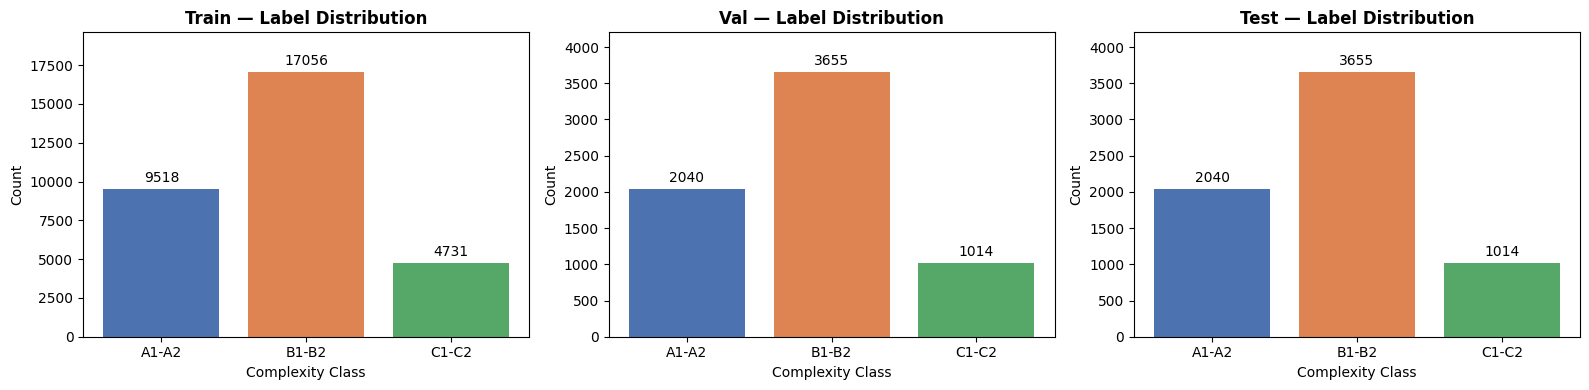

Train text length (words):
count    31305.000000
mean       236.367098
std        179.948955
min          4.000000
25%         83.000000
50%        195.000000
75%        358.000000
max       1656.000000


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

label_names = [CFG['id2label'][i] for i in range(CFG['num_labels'])]

for ax, (df, split) in zip(axes, [(train_df, 'Train'), (val_df, 'Val'), (test_df, 'Test')]):
    counts = df['label_enc'].value_counts().sort_index()
    bars = ax.bar([CFG['id2label'][i] for i in counts.index], counts.values,
                  color=['#4C72B0', '#DD8452', '#55A868'])
    ax.bar_label(bars, fmt='%d', padding=3)
    ax.set_title(f'{split} — Label Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Complexity Class')
    ax.set_ylabel('Count')
    ax.set_ylim(0, counts.max() * 1.15)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'label_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

# Text length stats
train_df['text_len'] = train_df['text_raw'].str.split().str.len()
print('Train text length (words):')
print(train_df['text_len'].describe().to_string())

## 5. Tokenization & Dataset Preparation

In [ ]:
print(f"Loading tokenizer: {CFG['model_name']}")
tokenizer = AutoTokenizer.from_pretrained(CFG['model_name'])
print(f'Vocab size: {tokenizer.vocab_size:,}')

Loading tokenizer: microsoft/deberta-v3-base


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Vocab size: 128,000


In [ ]:
class ComplexityDataset(Dataset):
    """PyTorch Dataset for text complexity classification."""

    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int):
        self.texts  = df['text_raw'].tolist()
        self.labels = df['label_enc'].tolist()
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids'     : encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'token_type_ids': encoding.get('token_type_ids', torch.zeros(self.max_length, dtype=torch.long)).squeeze(0),
            'labels'        : torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_dataset = ComplexityDataset(train_df, tokenizer, CFG['max_length'])
val_dataset   = ComplexityDataset(val_df,   tokenizer, CFG['max_length'])
test_dataset  = ComplexityDataset(test_df,  tokenizer, CFG['max_length'])

train_loader = DataLoader(train_dataset, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=CFG['num_workers'], pin_memory=CFG['pin_memory'])
val_loader   = DataLoader(val_dataset,   batch_size=CFG['batch_size'] * 2, shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=CFG['pin_memory'])
test_loader  = DataLoader(test_dataset,  batch_size=CFG['batch_size'] * 2, shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=CFG['pin_memory'])

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

# Quick sanity check
batch = next(iter(train_loader))
print(f'\nSample batch shapes:')
for k, v in batch.items():
    print(f'  {k}: {v.shape}')

Train batches : 1957
Val   batches : 210
Test  batches : 210

Sample batch shapes:
  input_ids: torch.Size([16, 256])
  attention_mask: torch.Size([16, 256])
  token_type_ids: torch.Size([16, 256])
  labels: torch.Size([16])


## 6. Model Initialization

In [ ]:
def build_model(cfg: dict) -> AutoModelForSequenceClassification:
    """Initialise a fresh DeBERTa classification head."""
    model = AutoModelForSequenceClassification.from_pretrained(
        cfg['model_name'],
        num_labels=cfg['num_labels'],
        id2label=cfg['id2label'],
        label2id=cfg['label2id'],
        ignore_mismatched_sizes=True,
    )
    return model


model = build_model(CFG)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias          

Total parameters    : 184,424,451
Trainable parameters: 184,424,451


In [ ]:
# ── Optimizer (no weight decay on bias / LayerNorm) ──
no_decay = ['bias', 'LayerNorm.weight', 'layernorm.weight']
optimizer_grouped_params = [
    {'params': [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
     'weight_decay': CFG['weight_decay']},
    {'params': [p for n, p in model.named_parameters() if     any(nd in n for nd in no_decay)],
     'weight_decay': 0.0},
]
optimizer = AdamW(optimizer_grouped_params, lr=CFG['learning_rate'], eps=1e-8)

# ── LR Scheduler ──
total_steps  = math.ceil(len(train_loader) / CFG['grad_accum_steps']) * CFG['epochs']
warmup_steps = int(total_steps * CFG['warmup_ratio'])

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

# ── Mixed precision scaler ──
scaler = torch.cuda.amp.GradScaler(enabled=CFG['fp16'] and DEVICE.type == 'cuda')

print(f'Total optimisation steps : {total_steps}')
print(f'Warmup steps             : {warmup_steps}')
print(f'Effective batch size     : {CFG["batch_size"] * CFG["grad_accum_steps"]}')

Total optimisation steps : 4895
Warmup steps             : 489
Effective batch size     : 32


## 7. Training

The custom training loop below supports:
- Gradient accumulation
- Mixed-precision (FP16)
- Per-epoch checkpointing with automatic cleanup
- Best-model selection by validation macro-F1
- Notebook-friendly progress bars with ETA, previous metrics, and best-score tracking


In [ ]:
# ─────────────────────────────────────────────
#  Helper: evaluation
# ─────────────────────────────────────────────
def evaluate(model, loader, device, split='Val'):
    """Run inference on a DataLoader and return loss, accuracy, macro-F1."""
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            labels         = batch['labels'].to(device)

            with torch.cuda.amp.autocast(enabled=CFG['fp16'] and device.type == 'cuda'):
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    token_type_ids=token_type_ids if token_type_ids.any() else None,
                    labels=labels,
                )

            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, acc, macro_f1, all_preds, all_labels


def ensure_history_schema(history):
    """Make resume-safe history dicts work with the richer progress UI."""
    history.setdefault('train_loss', [])
    history.setdefault('val_loss', [])
    history.setdefault('val_acc', [])
    history.setdefault('val_f1', [])
    history.setdefault('epoch_seconds', [])
    return history


def get_last_metric(history, key):
    values = history.get(key, [])
    return values[-1] if values else None


def format_metric(value, digits=4):
    return f'{value:.{digits}f}' if value is not None else '--'


def format_seconds(seconds):
    if seconds is None or not np.isfinite(seconds):
        return '--'

    seconds = max(int(seconds), 0)
    minutes, sec = divmod(seconds, 60)
    hours, minutes = divmod(minutes, 60)
    if hours:
        return f'{hours}h {minutes:02d}m {sec:02d}s'
    return f'{minutes:02d}m {sec:02d}s'


def estimate_total_eta(epoch, step, n_batches, epoch_start, history, cfg):
    """Estimate remaining training time from current progress and recent epochs."""
    elapsed = (datetime.now() - epoch_start).total_seconds()
    pct = (step + 1) / max(n_batches, 1)
    current_epoch_total = elapsed / max(pct, 1e-6)
    current_epoch_remaining = max(current_epoch_total - elapsed, 0.0)

    epoch_times = history.get('epoch_seconds', [])
    reference_times = epoch_times[-3:] if epoch_times else [current_epoch_total]
    avg_epoch_seconds = sum(reference_times) / len(reference_times)
    remaining_full_epochs = max(cfg['epochs'] - epoch, 0)
    return current_epoch_remaining + remaining_full_epochs * avg_epoch_seconds


def estimate_post_epoch_eta(epoch, history, cfg):
    epoch_times = history.get('epoch_seconds', [])
    if not epoch_times:
        return None

    avg_epoch_seconds = sum(epoch_times[-3:]) / len(epoch_times[-3:])
    remaining_epochs = max(cfg['epochs'] - epoch, 0)
    return remaining_epochs * avg_epoch_seconds


def build_progress_postfix(avg_loss, lr, history, best_val_f1, best_epoch, total_eta_seconds):
    return {
        'loss': f'{avg_loss:.4f}',
        'lr': f'{lr:.2e}',
        'prev_f1': format_metric(get_last_metric(history, 'val_f1')),
        'prev_acc': format_metric(get_last_metric(history, 'val_acc')),
        'best_f1': format_metric(best_val_f1 if best_val_f1 >= 0 else None),
        'best_ep': best_epoch if best_epoch else '--',
        'eta_all': format_seconds(total_eta_seconds),
    }


def display_epoch_summary(
    epoch,
    cfg,
    avg_train_loss,
    val_loss,
    val_acc,
    val_f1,
    prev_val_acc,
    prev_val_f1,
    epoch_seconds,
    eta_seconds,
    best_val_f1,
    best_epoch,
):
    summary = pd.DataFrame([
        {
            'epoch': f'{epoch}/{cfg["epochs"]}',
            'train_loss': avg_train_loss,
            'val_loss': val_loss,
            'prev_val_acc': prev_val_acc,
            'val_acc': val_acc,
            'delta_acc': None if prev_val_acc is None else val_acc - prev_val_acc,
            'prev_val_f1': prev_val_f1,
            'val_f1': val_f1,
            'delta_f1': None if prev_val_f1 is None else val_f1 - prev_val_f1,
            'best_f1': best_val_f1 if best_val_f1 >= 0 else None,
            'best_epoch': best_epoch if best_epoch else None,
            'epoch_time': format_seconds(epoch_seconds),
            'eta_left': format_seconds(eta_seconds),
        }
    ])

    display(
        summary.style.hide(axis='index').format(
            {
                'train_loss': '{:.4f}',
                'val_loss': '{:.4f}',
                'prev_val_acc': lambda x: '--' if pd.isna(x) else f'{x:.4f}',
                'val_acc': '{:.4f}',
                'delta_acc': lambda x: '--' if pd.isna(x) else f'{x:+.4f}',
                'prev_val_f1': lambda x: '--' if pd.isna(x) else f'{x:.4f}',
                'val_f1': '{:.4f}',
                'delta_f1': lambda x: '--' if pd.isna(x) else f'{x:+.4f}',
                'best_f1': lambda x: '--' if pd.isna(x) else f'{x:.4f}',
                'best_epoch': lambda x: '--' if pd.isna(x) else f'{int(x)}',
            }
        )
    )


# ─────────────────────────────────────────────
#  Helper: checkpoint management
# ─────────────────────────────────────────────
def save_checkpoint(model, optimizer, scheduler, scaler, epoch, metrics, cfg):
    """Save a training checkpoint and remove old ones beyond keep_last_n."""
    ckpt_path = Path(cfg['checkpoint_dir']) / f'checkpoint_epoch_{epoch}'
    ckpt_path.mkdir(parents=True, exist_ok=True)

    # Save model + tokenizer
    model.save_pretrained(str(ckpt_path))
    tokenizer.save_pretrained(str(ckpt_path))

    # Save training state
    state = {
        'epoch'           : epoch,
        'optimizer_state' : optimizer.state_dict(),
        'scheduler_state' : scheduler.state_dict(),
        'scaler_state'    : scaler.state_dict(),
        'metrics'         : metrics,
    }
    torch.save(state, str(ckpt_path / 'training_state.pt'))

    # Prune old checkpoints
    ckpt_root = Path(cfg['checkpoint_dir'])
    all_ckpts = sorted(
        [d for d in ckpt_root.iterdir() if d.is_dir() and d.name.startswith('checkpoint_epoch_')],
        key=lambda d: int(d.name.split('_')[-1])
    )
    while len(all_ckpts) > cfg['keep_last_n_ckpts']:
        shutil.rmtree(all_ckpts.pop(0))

    print(f'  [checkpoint] Saved {ckpt_path.name}')
    return str(ckpt_path)


def get_latest_checkpoint(cfg):
    """Return path to the most recent checkpoint, or None."""
    ckpt_root = Path(cfg['checkpoint_dir'])
    all_ckpts = sorted(
        [d for d in ckpt_root.iterdir() if d.is_dir() and d.name.startswith('checkpoint_epoch_')],
        key=lambda d: int(d.name.split('_')[-1])
    ) if ckpt_root.exists() else []
    return str(all_ckpts[-1]) if all_ckpts else None


def save_history(history, cfg):
    """Persist training history dict to JSON."""
    with open(cfg['history_file'], 'w') as f:
        json.dump(history, f, indent=2)


print('Helper functions defined.')


Helper functions defined.


In [ ]:
# ─────────────────────────────────────────────
#  Main training loop
# ─────────────────────────────────────────────
history = ensure_history_schema({
    'train_loss': [], 'val_loss': [],
    'val_acc'   : [], 'val_f1'  : [],
})

best_val_f1 = -1.0
best_epoch  = 0
global_step = 0

print(f'Starting training for {CFG["epochs"]} epoch(s)...\n')
train_start = datetime.now()

for epoch in range(1, CFG['epochs'] + 1):
    model.train()
    epoch_loss  = 0.0
    n_batches   = len(train_loader)
    epoch_start = datetime.now()
    prev_val_acc = get_last_metric(history, 'val_acc')
    prev_val_f1  = get_last_metric(history, 'val_f1')
    optimizer.zero_grad()

    print(f'{"─"*60}')
    print(f'Epoch {epoch}/{CFG["epochs"]}')
    print(f'{"─"*60}')

    progress = tqdm(
        train_loader,
        total=n_batches,
        desc=f'Epoch {epoch}/{CFG["epochs"]}',
        dynamic_ncols=True,
        leave=True,
        colour='#2563EB',
        bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]',
    )

    for step, batch in enumerate(progress, start=1):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        token_type_ids = batch['token_type_ids'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        with torch.cuda.amp.autocast(enabled=CFG['fp16'] and DEVICE.type == 'cuda'):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids if token_type_ids.any() else None,
                labels=labels,
            )
            loss = outputs.loss / CFG['grad_accum_steps']

        scaler.scale(loss).backward()

        if step % CFG['grad_accum_steps'] == 0 or step == n_batches:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['max_grad_norm'])
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()
            global_step += 1

        epoch_loss += outputs.loss.item()

        if step % max(1, n_batches // 40) == 0 or step == n_batches:
            avg_loss = epoch_loss / step
            lr = scheduler.get_last_lr()[0]
            total_eta_seconds = estimate_total_eta(epoch, step - 1, n_batches, epoch_start, history, CFG)
            progress.set_postfix(
                build_progress_postfix(avg_loss, lr, history, best_val_f1, best_epoch, total_eta_seconds),
                refresh=False,
            )

    progress.close()

    epoch_seconds = (datetime.now() - epoch_start).total_seconds()
    avg_train_loss = epoch_loss / n_batches
    print(f'\n  Train loss : {avg_train_loss:.4f}')

    val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, DEVICE, 'Val')
    print(f'  Val   loss : {val_loss:.4f}  |  acc={val_acc:.4f}  |  macro-F1={val_f1:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch  = epoch
        model.save_pretrained(CFG['best_model_dir'])
        tokenizer.save_pretrained(CFG['best_model_dir'])
        print(f'  [best] Updated best model (val macro-F1={val_f1:.4f})')

    history['epoch_seconds'].append(epoch_seconds)
    eta_after_epoch = estimate_post_epoch_eta(epoch, history, CFG)
    display_epoch_summary(
        epoch=epoch,
        cfg=CFG,
        avg_train_loss=avg_train_loss,
        val_loss=val_loss,
        val_acc=val_acc,
        val_f1=val_f1,
        prev_val_acc=prev_val_acc,
        prev_val_f1=prev_val_f1,
        epoch_seconds=epoch_seconds,
        eta_seconds=eta_after_epoch,
        best_val_f1=best_val_f1,
        best_epoch=best_epoch,
    )

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    save_history(history, CFG)

    if epoch % CFG['save_every_n_epochs'] == 0:
        metrics_snapshot = {
            'train_loss': avg_train_loss,
            'val_loss'  : val_loss,
            'val_acc'   : val_acc,
            'val_f1'    : val_f1,
            'epoch_seconds': epoch_seconds,
        }
        save_checkpoint(model, optimizer, scheduler, scaler, epoch, metrics_snapshot, CFG)

total_time = datetime.now() - train_start
print(f'\n{"="*60}')
print(f'Training complete in {str(total_time).split(".")[0]}')
print(f'Best val macro-F1: {best_val_f1:.4f} at epoch {best_epoch}')
print(f'{"="*60}')


Starting training for 5 epoch(s)...

────────────────────────────────────────────────────────────
Epoch 1/5
────────────────────────────────────────────────────────────


Epoch 1/5:   0%|          | 0/1957 [00:00<?, ?it/s]


  Train loss : 0.7861
  Val   loss : 0.7288  |  acc=0.7011  |  macro-F1=0.6567
  [best] Updated best model (val macro-F1=0.6567)


epoch,train_loss,val_loss,prev_val_acc,val_acc,delta_acc,prev_val_f1,val_f1,delta_f1,best_f1,best_epoch,epoch_time,eta_left
1/5,0.7861,0.7288,--,0.7011,--,--,0.6567,--,0.6567,1,14m 09s,56m 37s


  [checkpoint] Saved checkpoint_epoch_1
────────────────────────────────────────────────────────────
Epoch 2/5
────────────────────────────────────────────────────────────


...


  Train loss : 0.3535
  Val   loss : 0.6160  |  acc=0.7620  |  macro-F1=0.7438


epoch,train_loss,val_loss,prev_val_acc,val_acc,delta_acc,prev_val_f1,val_f1,delta_f1,best_f1,best_epoch,epoch_time,eta_left
4/5,0.3535,0.6160,0.7758,0.7620,-0.0139,0.7473,0.7438,-0.0035,0.7473,3,14m 15s,14m 15s


  [checkpoint] Saved checkpoint_epoch_4
────────────────────────────────────────────────────────────
Epoch 5/5
────────────────────────────────────────────────────────────


Epoch 5/5:   0%|          | 0/1957 [00:00<?, ?it/s]


  Train loss : 0.2900


## 8. Resume Training from Latest Checkpoint

> **Run this cell only if the training crashed and you want to continue from where it left off.**  
> Skip it if training completed normally.

In [ ]:
# ─────────────────────────────────────────────
#  Resume from latest checkpoint
#  (Skip if training already finished)
# ─────────────────────────────────────────────

RESUME = True   # <- Set to True to actually resume

if RESUME:
    latest_ckpt = get_latest_checkpoint(CFG)
    if latest_ckpt is None:
        print('No checkpoint found - starting fresh.')
    else:
        print(f'Resuming from: {latest_ckpt}')

        # Reload model & tokenizer
        model = AutoModelForSequenceClassification.from_pretrained(latest_ckpt)
        tokenizer = AutoTokenizer.from_pretrained(latest_ckpt)
        model = model.to(DEVICE)

        # Restore optimizer / scheduler / scaler
        state = torch.load(str(Path(latest_ckpt) / 'training_state.pt'), map_location=DEVICE)
        optimizer.load_state_dict(state['optimizer_state'])
        scheduler.load_state_dict(state['scheduler_state'])
        scaler.load_state_dict(state['scaler_state'])

        start_epoch = state['epoch'] + 1
        print(f'Resuming from epoch {start_epoch}.')

        hist_path = Path(CFG['history_file'])
        if hist_path.exists():
            with open(hist_path) as f:
                history = ensure_history_schema(json.load(f))
        else:
            history = ensure_history_schema({
                'train_loss': [], 'val_loss': [],
                'val_acc': [], 'val_f1': [],
            })

        if history['val_f1']:
            best_val_f1 = max(history['val_f1'])
            best_epoch = history['val_f1'].index(best_val_f1) + 1
        else:
            best_val_f1 = -1.0
            best_epoch = 0

        print(f'Loaded history: {len(history["train_loss"])} epochs recorded.')
        print(f'Best val macro-F1 so far: {format_metric(best_val_f1 if best_val_f1 >= 0 else None)}')

        for epoch in range(start_epoch, CFG['epochs'] + 1):
            model.train()
            epoch_loss = 0.0
            n_batches = len(train_loader)
            prev_val_acc = get_last_metric(history, 'val_acc')
            prev_val_f1 = get_last_metric(history, 'val_f1')
            optimizer.zero_grad()
            epoch_start = datetime.now()

            print(f'\n{"─"*60}\nEpoch {epoch}/{CFG["epochs"]}\n{"─"*60}')

            progress = tqdm(
                train_loader,
                total=n_batches,
                desc=f'Epoch {epoch}/{CFG["epochs"]}',
                dynamic_ncols=True,
                leave=True,
                colour='#0F766E',
                bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]',
            )

            for step, batch in enumerate(progress, start=1):
                input_ids      = batch['input_ids'].to(DEVICE)
                attention_mask = batch['attention_mask'].to(DEVICE)
                token_type_ids = batch['token_type_ids'].to(DEVICE)
                labels         = batch['labels'].to(DEVICE)

                with torch.cuda.amp.autocast(enabled=CFG['fp16'] and DEVICE.type == 'cuda'):
                    outputs = model(
                        input_ids=input_ids,
                        attention_mask=attention_mask,
                        token_type_ids=token_type_ids if token_type_ids.any() else None,
                        labels=labels,
                    )
                    loss = outputs.loss / CFG['grad_accum_steps']

                scaler.scale(loss).backward()

                if step % CFG['grad_accum_steps'] == 0 or step == n_batches:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['max_grad_norm'])
                    scaler.step(optimizer)
                    scaler.update()
                    scheduler.step()
                    optimizer.zero_grad()

                epoch_loss += outputs.loss.item()

                if step % max(1, n_batches // 40) == 0 or step == n_batches:
                    avg_loss = epoch_loss / step
                    lr = scheduler.get_last_lr()[0]
                    total_eta_seconds = estimate_total_eta(epoch, step - 1, n_batches, epoch_start, history, CFG)
                    progress.set_postfix(
                        build_progress_postfix(avg_loss, lr, history, best_val_f1, best_epoch, total_eta_seconds),
                        refresh=False,
                    )

            progress.close()

            epoch_seconds = (datetime.now() - epoch_start).total_seconds()
            avg_train_loss = epoch_loss / n_batches
            print(f'\n  Train loss : {avg_train_loss:.4f}')

            val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, DEVICE, split='Val')
            print(f'  Val   loss : {val_loss:.4f}  |  acc={val_acc:.4f}  |  macro-F1={val_f1:.4f}')

            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_epoch  = epoch
                model.save_pretrained(CFG['best_model_dir'])
                tokenizer.save_pretrained(CFG['best_model_dir'])
                print(f'  [best] Updated best model (val macro-F1={val_f1:.4f})')

            history['epoch_seconds'].append(epoch_seconds)
            eta_after_epoch = estimate_post_epoch_eta(epoch, history, CFG)
            display_epoch_summary(
                epoch=epoch,
                cfg=CFG,
                avg_train_loss=avg_train_loss,
                val_loss=val_loss,
                val_acc=val_acc,
                val_f1=val_f1,
                prev_val_acc=prev_val_acc,
                prev_val_f1=prev_val_f1,
                epoch_seconds=epoch_seconds,
                eta_seconds=eta_after_epoch,
                best_val_f1=best_val_f1,
                best_epoch=best_epoch,
            )

            history['train_loss'].append(avg_train_loss)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            history['val_f1'].append(val_f1)
            save_history(history, CFG)

            if epoch % CFG['save_every_n_epochs'] == 0:
                save_checkpoint(
                    model,
                    optimizer,
                    scheduler,
                    scaler,
                    epoch,
                    {
                        'train_loss': avg_train_loss,
                        'val_loss': val_loss,
                        'val_acc': val_acc,
                        'val_f1': val_f1,
                        'epoch_seconds': epoch_seconds,
                    },
                    CFG,
                )

        print('Resume training complete.')
else:
    print('RESUME=False - skipping resume cell.')


NameError: name 'get_latest_checkpoint' is not defined

## 9. Final Evaluation on Test Set

Load the **best model** (selected by validation macro-F1) and evaluate on the held-out test set.

In [ ]:
print(f'Loading best model from: {CFG["best_model_dir"]}')
best_model = AutoModelForSequenceClassification.from_pretrained(CFG['best_model_dir'])
best_model = best_model.to(DEVICE)

test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(
    best_model, test_loader, DEVICE, split='Test'
)

print(f'\n{'='*50}')
print(f'TEST SET RESULTS')
print(f'{'='*50}')
print(f'  Loss     : {test_loss:.4f}')
print(f'  Accuracy : {test_acc:.4f}')
print(f'  Macro-F1 : {test_f1:.4f}')
print(f'{'='*50}')

# ── Full classification report ──
target_names = [CFG['id2label'][i] for i in range(CFG['num_labels'])]
report = classification_report(test_labels, test_preds, target_names=target_names, digits=4)
print('\nClassification Report:')
print(report)

In [ ]:
# ── Confusion matrix ──
cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Confusion Matrix (counts)', 'Confusion Matrix (normalised)'],
):
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=target_names, yticklabels=target_names,
        ax=ax, linewidths=0.5, cbar=True,
    )
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle(
    f'Test Set — Accuracy: {test_acc:.4f} | Macro-F1: {test_f1:.4f}',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Save Final Model & Results

In [ ]:
# ── Save final model & tokenizer ──
best_model.save_pretrained(CFG['final_model_dir'])
tokenizer.save_pretrained(CFG['final_model_dir'])
print(f'Final model saved to: {CFG["final_model_dir"]}')

# ── Save evaluation results ──
results = {
    'model_name'     : CFG['model_name'],
    'best_val_epoch' : best_epoch,
    'best_val_f1'    : best_val_f1,
    'test_loss'      : test_loss,
    'test_accuracy'  : test_acc,
    'test_macro_f1'  : test_f1,
    'classification_report': classification_report(
        test_labels, test_preds,
        target_names=target_names,
        digits=4,
        output_dict=True,
    ),
    'config': {k: v for k, v in CFG.items() if k not in ['id2label', 'label2id']},
    'training_history': history,
}

with open(CFG['results_file'], 'w') as f:
    json.dump(results, f, indent=2)

print(f'Evaluation results saved to: {CFG["results_file"]}')
print('\nAll outputs in the experiment directory:')
for p in sorted(Path(CFG['output_dir']).rglob('*')):
    if p.is_file():
        print(f'  {p.relative_to(CFG["output_dir"])}')

## 11. Plot Training History

In [ ]:
# ── Optionally reload history from file (useful after resume) ──
hist_path = Path(CFG['history_file'])
if hist_path.exists():
    with open(hist_path) as f:
        history = json.load(f)

epochs_x = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Training History — DeBERTa-v3-base Text Complexity', fontsize=14, fontweight='bold')

# ── Loss ──
ax = axes[0]
ax.plot(epochs_x, history['train_loss'], 'o-', color='#4C72B0', label='Train Loss', linewidth=2)
ax.plot(epochs_x, history['val_loss'],   's--', color='#DD8452', label='Val Loss',   linewidth=2)
ax.set_title('Loss', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks(list(epochs_x))

# ── Accuracy ──
ax = axes[1]
ax.plot(epochs_x, history['val_acc'], 'o-', color='#55A868', linewidth=2, marker='o')
best_idx = history['val_acc'].index(max(history['val_acc']))
ax.scatter([best_idx + 1], [history['val_acc'][best_idx]], s=150, zorder=5,
           color='red', label=f'Best: {history["val_acc"][best_idx]:.4f}')
ax.set_title('Validation Accuracy', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks(list(epochs_x))

# ── Macro-F1 ──
ax = axes[2]
ax.plot(epochs_x, history['val_f1'], 'o-', color='#C44E52', linewidth=2, marker='o')
best_f1_idx = history['val_f1'].index(max(history['val_f1']))
ax.scatter([best_f1_idx + 1], [history['val_f1'][best_f1_idx]], s=150, zorder=5,
           color='darkred', label=f'Best: {history["val_f1"][best_f1_idx]:.4f}')
ax.set_title('Validation Macro-F1', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Macro-F1')
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks(list(epochs_x))

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nFinal Summary')
print(f'{"─"*40}')
print(f'  Best Epoch (by val F1) : {best_epoch}')
print(f'  Best Val Macro-F1      : {best_val_f1:.4f}')
print(f'  Test Accuracy          : {test_acc:.4f}')
print(f'  Test Macro-F1          : {test_f1:.4f}')
print(f'{"─"*40}')